In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Cleaned_Production_Data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Start_Hour,End_Hour,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,...,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes
0,2025-11-30,21,22,334,5281,11.8,72,0.0,5.9,1,...,0,0,0,0,0,0,1,0,0,0
1,2025-11-30,18,19,334,3824,13.5,67,0.0,7.2,1,...,0,0,0,0,0,0,1,0,0,0
2,2025-11-30,16,17,334,3824,17.3,50,0.0,5.1,1,...,0,0,0,0,0,0,1,0,0,0
3,2025-11-30,23,0,334,6120,10.4,69,0.0,5.4,1,...,0,0,0,0,0,0,1,0,0,0
4,2025-11-30,6,7,334,4387,8.2,62,0.0,1.6,1,...,0,0,0,0,0,0,1,0,0,0


In [5]:
# Convert 'Date' column to datetime objects
# Defensive reload of df if 'Date' column is missing (due to prior modifications)
if 'Date' not in df.columns:
    print("Warning: 'Date' column not found. Reloading DataFrame to ensure original 'Date' column is present.")
    df = pd.read_csv('/content/Cleaned_Production_Data.csv')

df['Date'] = pd.to_datetime(df['Date'])

# Extract year, month, and day as new features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Convert the 'Date' column to Unix timestamp (numerical) for model compatibility
df['Date'] = df['Date'].astype(int) / 10**9 # Convert to seconds

# Display the first few rows with the new features
display(df.head())

,Date,Start_Hour,End_Hour,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,...,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes,Year,Month,Day
0,1.764461e+09,21,22,334,5281,11.8,72,0.0,5.9,1,...,0,0,0,1,0,0,0,2025,11,30
1,1.764461e+09,18,19,334,3824,13.5,67,0.0,7.2,1,...,0,0,0,1,0,0,0,2025,11,30
2,1.764461e+09,16,17,334,3824,17.3,50,0.0,5.1,1,...,0,0,0,1,0,0,0,2025,11,30
3,1.764461e+09,23,0,334,6120,10.4,69,0.0,5.4,1,...,0,0,0,1,0,0,0,2025,11,30
4,1.764461e+09,6,7,334,4387,8.2,62,0.0,1.6,1,...,0,0,0,1,0,0,0,2025,11,30


In [6]:
# Ensure 'Date' column is numerical before proceeding, in case it was not processed correctly earlier
import pandas as pd
if 'Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Date']):
    print("Converting 'Date' column to numerical Unix timestamp (defensive measure).")
    df['Date'] = df['Date'].astype(int) / 10**9

# Check if 'Source_Wind' column exists and needs one-hot encoding
if 'Source_Wind' in df.columns:
    print("Unique values in Source_Wind:", df['Source_Wind'].unique())
    print("Data type of Source_Wind:", df['Source_Wind'].dtype)
    # One-hot encode 'Source_Wind' if it's categorical and not already encoded
    if df['Source_Wind'].dtype == 'int64' and len(df['Source_Wind'].unique()) < 10: # Heuristic for categorical
        df = pd.get_dummies(df, columns=['Source_Wind'], prefix='Source_Wind')
        print("One-hot encoded 'Source_Wind'.")
else:
    print("'Source_Wind' column not found. Assuming it was already one-hot encoded.")

# Define features (X) and target (y)
X = df.drop('Production', axis=1)
y = df['Production']

print("\nShape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

display(X.head())

Unique values in Source_Wind: [1 0]
Data type of Source_Wind: int64
One-hot encoded 'Source_Wind'.

Shape of features (X): (51862, 34)
Shape of target (y): (51862,)


,Date,Start_Hour,End_Hour,Day_of_Year,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Season_Spring,Season_Summer,...,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes,Year,Month,Day,Source_Wind_0,Source_Wind_1
0,1.764461e+09,21,22,334,11.8,72,0.0,5.9,0,0,...,0,1,0,0,0,2025,11,30,False,True
1,1.764461e+09,18,19,334,13.5,67,0.0,7.2,0,0,...,0,1,0,0,0,2025,11,30,False,True
2,1.764461e+09,16,17,334,17.3,50,0.0,5.1,0,0,...,0,1,0,0,0,2025,11,30,False,True
3,1.764461e+09,23,0,334,10.4,69,0.0,5.4,0,0,...,0,1,0,0,0,2025,11,30,False,True
4,1.764461e+09,6,7,334,8.2,62,0.0,1.6,0,0,...,0,1,0,0,0,2025,11,30,False,True


In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Ensure 'Date' column in X is numerical if it exists and is still datetime
if 'Date' in X.columns and pd.api.types.is_datetime64_any_dtype(X['Date']):
    print("Defensively converting 'Date' column in X to numerical Unix timestamp before splitting.")
    X['Date'] = X['Date'].astype(int) / 10**9

# Ensure boolean columns are treated as integers (0 or 1) in X
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (41489, 34)
Shape of X_test: (10373, 34)
Shape of y_train: (41489,)
Shape of y_test: (10373,)


In [8]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Defensive conversions before scaling to ensure all data is numerical
def convert_to_numerical(df_input):
    df_copy = df_input.copy()
    if 'Date' in df_copy.columns and pd.api.types.is_datetime64_any_dtype(df_copy['Date']):
        print("Defensively converting 'Date' column to numerical Unix timestamp before scaling.")
        df_copy['Date'] = df_copy['Date'].astype(int) / 10**9
    for col in df_copy.select_dtypes(include='bool').columns:
        print(f"Defensively converting boolean column '{col}' to int before scaling.")
        df_copy[col] = df_copy[col].astype(int)
    return df_copy

X_train_numeric = convert_to_numerical(X_train)
X_test_numeric = convert_to_numerical(X_test)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

# Display the first few rows of the scaled training data (as DataFrame for better readability)
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Shape of X_train_scaled: (41489, 34)
Shape of X_test_scaled: (10373, 34)


,Date,Start_Hour,End_Hour,Day_of_Year,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Season_Spring,Season_Summer,...,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes,Year,Month,Day,Source_Wind_0,Source_Wind_1
0,1.053273,-0.940296,-0.795891,0.918976,0.213090,-0.364966,-0.170859,-1.177845,-0.583241,-0.58454,...,-0.305611,-0.302252,3.243690,-0.302537,-0.354808,0.907492,1.039328,-1.448113,-0.469400,0.469400
1,-0.000768,-0.073322,0.070935,1.617977,-0.563468,-0.765946,-0.170859,-1.333536,-0.583241,-0.58454,...,-0.305611,-0.302252,-0.308291,-0.302537,-0.354808,-0.274363,1.624956,0.027261,-0.469400,0.469400
2,-0.060128,0.071173,0.215406,1.263689,-0.551141,0.637484,3.835664,1.261309,-0.583241,-0.58454,...,-0.305611,3.308498,-0.308291,-0.302537,2.818426,-0.274363,1.332142,-0.767171,-0.469400,0.469400
3,-0.732340,-0.362314,-0.218007,0.746620,0.878711,0.186382,-0.170859,-0.347495,-0.583241,-0.58454,...,-0.305611,-0.302252,-0.308291,3.305382,-0.354808,-0.865290,0.746514,0.027261,2.130379,-2.130379
4,-1.162299,1.660626,-1.662716,1.685004,-1.561899,1.138709,-0.170859,-0.399392,-0.583241,-0.58454,...,-0.305611,-0.302252,-0.308291,-0.302537,-0.354808,-1.456217,1.624956,0.708203,-0.469400,0.469400


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

print("RandomForestRegressor model trained successfully!")

RandomForestRegressor model trained successfully!


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 1069.65
Mean Squared Error (MSE): 2687000.71
Root Mean Squared Error (RMSE): 1639.21
R-squared (R2): 0.83


### Actual vs. Predicted Values (Random Forest)

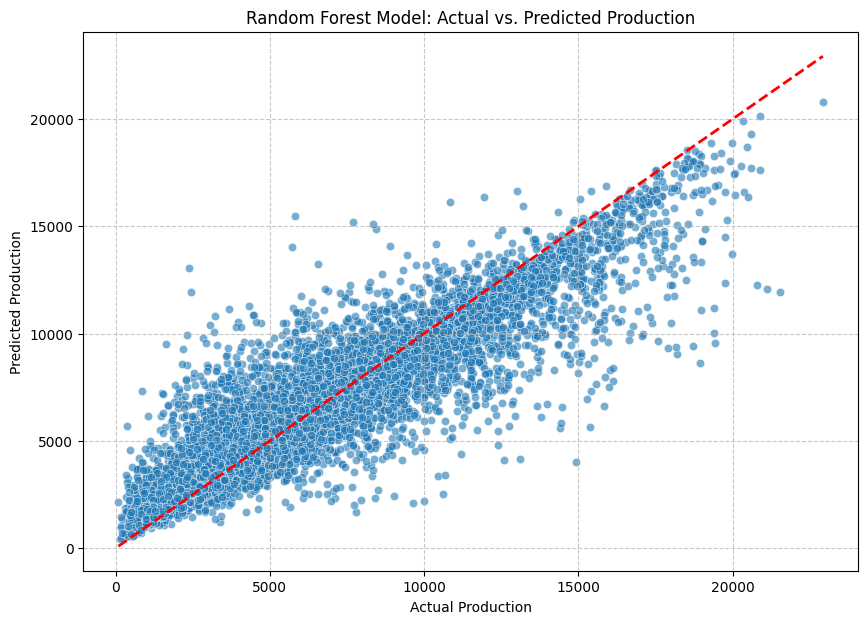

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Random Forest Model: Actual vs. Predicted Production")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Hyperparameter Tuning for Random Forest Regressor

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 5],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]  # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,  # Use all available CPU cores
    verbose=2, # Verbose output
    scoring='neg_mean_squared_error' # Optimize for RMSE (negated for GridSearchCV)
)

print("Starting GridSearchCV for Random Forest...")
# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_scaled, y_train)

print("GridSearchCV for Random Forest completed.")
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best RMSE for Random Forest (on CV): {-grid_search_rf.best_score_**0.5:.2f}")

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV for Random Forest completed.
Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RMSE for Random Forest (on CV): nan


/tmp/ipykernel_34599/753367024.py:28: RuntimeWarning: invalid value encountered in scalar power
  print(f"Best RMSE for Random Forest (on CV): {-grid_search_rf.best_score_**0.5:.2f}")


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions using the best Random Forest model
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)

# Evaluate the best Random Forest model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_rf_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf_tuned:.2f}")
print(f"R-squared (R2): {r2_rf_tuned:.2f}")

Tuned Random Forest Regressor Evaluation:
Mean Absolute Error (MAE): 1068.79
Mean Squared Error (MSE): 2678536.86
Root Mean Squared Error (RMSE): 1636.62
R-squared (R2): 0.83


### Actual vs. Predicted Values (Tuned Random Forest)

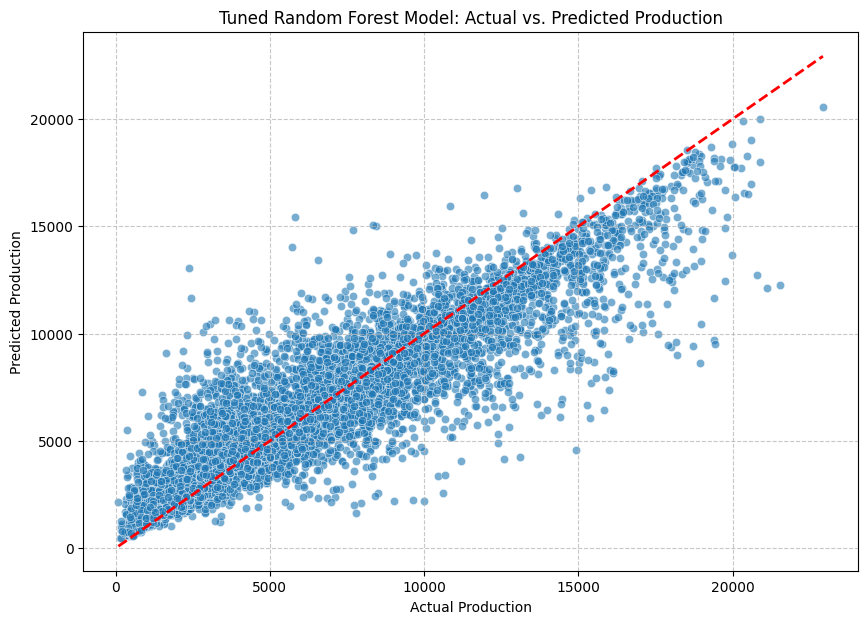

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_rf_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Tuned Random Forest Model: Actual vs. Predicted Production")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### XGBoost Regressor Model

In [15]:
import xgboost as xgb

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)

# Train the model on the scaled training data
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost Regressor model trained successfully!")

XGBoost Regressor model trained successfully!


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the scaled test data using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Calculate evaluation metrics for XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")

XGBoost Regressor Evaluation:
Mean Absolute Error (MAE): 1436.63
Mean Squared Error (MSE): 3562145.00
Root Mean Squared Error (RMSE): 1887.36
R-squared (R2): 0.77


### Actual vs. Predicted Values (XGBoost)

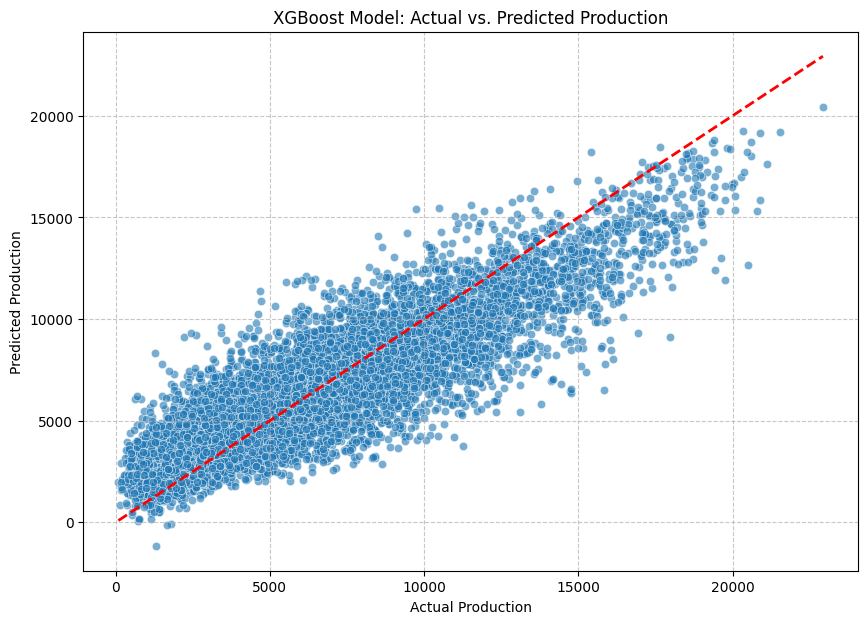

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("XGBoost Model: Actual vs. Predicted Production")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Hyperparameter Tuning for XGBoost Regressor

In [18]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 1.0]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, eval_metric='rmse'),
    param_grid=param_grid_xgb,
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
)

print("Starting GridSearchCV for XGBoost...")
# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train_scaled, y_train)

print("GridSearchCV for XGBoost completed.")
print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best RMSE for XGBoost (on CV): {-grid_search_xgb.best_score_**0.5:.2f}")

# Get the best model
best_xgb_model = grid_search_xgb.best_estimator_

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
GridSearchCV for XGBoost completed.
Best parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 9, 'n_estimators': 200, 'subsample': 1.0}
Best RMSE for XGBoost (on CV): nan


/tmp/ipykernel_34599/3767379929.py:28: RuntimeWarning: invalid value encountered in scalar power
  print(f"Best RMSE for XGBoost (on CV): {-grid_search_xgb.best_score_**0.5:.2f}")


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions using the best XGBoost model
y_pred_xgb_tuned = best_xgb_model.predict(X_test_scaled)

# Evaluate the best XGBoost model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("Tuned XGBoost Regressor Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_xgb_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.2f}")
print(f"R-squared (R2): {r2_xgb_tuned:.2f}")

Tuned XGBoost Regressor Evaluation:
Mean Absolute Error (MAE): 930.90
Mean Squared Error (MSE): 1681272.12
Root Mean Squared Error (RMSE): 1296.64
R-squared (R2): 0.89


### Actual vs. Predicted Values (Tuned XGBoost)

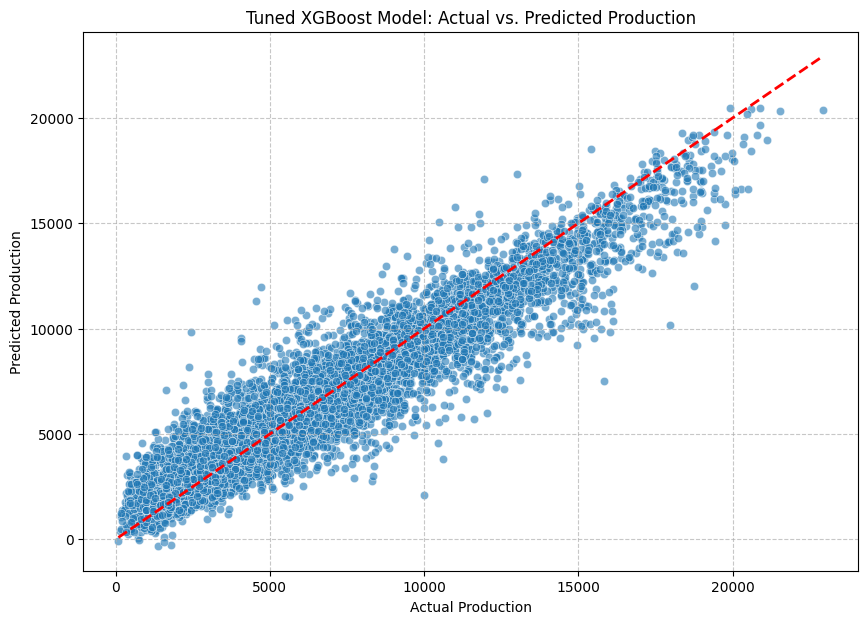

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_xgb_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Tuned XGBoost Model: Actual vs. Predicted Production")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Linear Regression Model

In [21]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model on the scaled training data
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the scaled test data using the Linear Regression model
y_pred_linear = linear_model.predict(X_test_scaled)

# Calculate evaluation metrics for Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Evaluation:")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

Linear Regression Evaluation:
Mean Absolute Error (MAE): 2858.64
Mean Squared Error (MSE): 12973923.09
Root Mean Squared Error (RMSE): 3601.93
R-squared (R2): 0.18


### Actual vs. Predicted Values (Linear Regression)

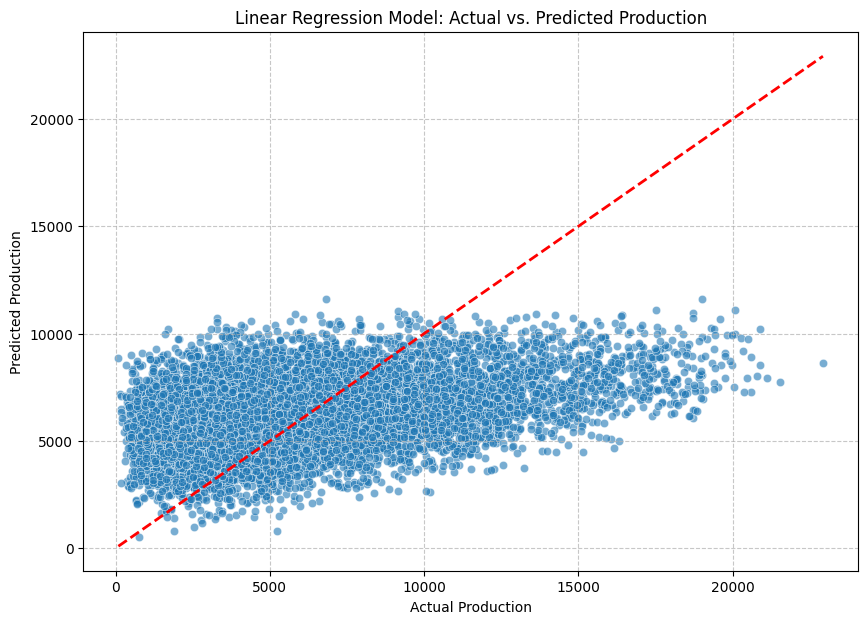

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_linear, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Linear Regression Model: Actual vs. Predicted Production")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()